# **Waze Project**
**Course 5 - Regression analysis: Simplify complex data relationships**

Your team is more than halfway through their user churn project. Earlier, you completed a project proposal, used Python to explore and analyze Waze’s user data, created data visualizations, and conducted a hypothesis test. Now, leadership wants your team to build a regression model to predict user churn based on a variety of variables.

You check your inbox and discover a new email from Ursula Sayo, Waze's Operations Manager. Ursula asks your team about the details of the regression model. You also notice two follow-up emails from your supervisor, May Santner. The first email is a response to Ursula, and says that the team will build a binomial logistic regression model. In her second email, May asks you to help build the model and prepare an executive summary to share your results.

A notebook was structured and prepared to help you in this project. Please complete the following questions and prepare an executive summary.

# **Course 5 End-of-course project: Regression modeling**

In this activity, you will build a binomial logistic regression model. As you have learned, logistic regression helps you estimate the probability of an outcome. For data science professionals, this is a useful skill because it allows you to consider more than one variable against the variable you're measuring against. This opens the door for much more thorough and flexible analysis to be completed.
<br/>

**The purpose** of this project is to demostrate knowledge of exploratory data analysis (EDA) and a binomial logistic regression model.

**The goal** is to build a binomial logistic regression model and evaluate the model's performance.
<br/>

*This activity has three parts:*

**Part 1:** EDA & Checking Model Assumptions
* What are some purposes of EDA before constructing a binomial logistic regression model?

**Part 2:** Model Building and Evaluation
* What resources do you find yourself using as you complete this stage?

**Part 3:** Interpreting Model Results

* What key insights emerged from your model(s)?

* What business recommendations do you propose based on the models built?

<br/>

Follow the instructions and answer the question below to complete the activity. Then, you will complete an executive summary using the questions listed on the PACE Strategy Document.

Be sure to complete this activity before moving on. The next course item will provide you with a completed exemplar to compare to your own work.

# **Build a regression model**

<img src="images/Pace.png" width="100" height="100" align=left>

# **PACE stages**


Throughout these project notebooks, you'll see references to the problem-solving framework PACE. The following notebook components are labeled with the respective PACE stage: Plan, Analyze, Construct, and Execute.

<img src="images/Plan.png" width="100" height="100" align=left>


## **PACE: Plan**
Consider the questions in your PACE Strategy Document to reflect on the Plan stage.

### **Task 1. Imports and data loading**
Import the data and packages that you've learned are needed for building logistic regression models.

In [1]:
# Packages for numerics + dataframes
import pandas as pd
import numpy as np

# Packages for visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Packages for Logistic Regression & Confusion Matrix
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix, classification_report, accuracy_score, 
    precision_score, recall_score, f1_score, roc_auc_score, RocCurveDisplay
)

Import the dataset.

**Note:** As shown in this cell, the dataset has been automatically loaded in for you. You do not need to download the .csv file, or provide more code, in order to access the dataset and proceed with this lab. Please continue with this activity by completing the following instructions.

In [2]:
# Load the dataset by running this cell

df = pd.read_csv('waze_dataset.csv')

<img src="images/Analyze.png" width="100" height="100" align=left>

## **PACE: Analyze**

Consider the questions in your PACE Strategy Document to reflect on the Analyze stage.

In this stage, consider the following question:

* What are some purposes of EDA before constructing a binomial logistic regression model?

Exploratory Data Analysis (EDA) serves several important purposes before constructing a binomial logistic regression model, including:

Data Understanding:
EDA helps you gain an initial understanding of the data structure, types, and distributions, ensuring you're familiar with the data you're modeling.

Identify Missing Values and Outliers:
EDA helps detect and handle missing values, anomalies, and outliers that could negatively affect the accuracy of the regression model.

Feature Selection and Engineering:
It assists in selecting relevant features by analyzing relationships between predictors and the target variable, guiding the inclusion or exclusion of variables.

Assessing Relationships and Multicollinearity:
Through correlation matrices and visualization, EDA can uncover multicollinearity (high correlations between predictors) that may cause instability in logistic regression coefficients.

Evaluating Assumptions:
Logistic regression assumes a linear relationship between log-odds of the outcome and predictors. EDA helps assess and visualize these assumptions.

Preparation for Modeling:
The insights gained through EDA guide preprocessing tasks such as scaling, encoding categorical variables, and transforming skewed data, ensuring the data is suitable for logistic regression.

### **Task 2a. Explore data with EDA**

Analyze and discover data, looking for correlations, missing data, potential outliers, and/or duplicates.



Start with `.shape` and `info()`.

In [3]:
# Inspect dataset dimensions
print(f'Dataset dimensions: {df.shape}')

# Inspect dataset structure, data types, and missing values
df.info()


Dataset dimensions: (14999, 13)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   ID                       14999 non-null  int64  
 1   label                    14299 non-null  object 
 2   sessions                 14999 non-null  int64  
 3   drives                   14999 non-null  int64  
 4   total_sessions           14999 non-null  float64
 5   n_days_after_onboarding  14999 non-null  int64  
 6   total_navigations_fav1   14999 non-null  int64  
 7   total_navigations_fav2   14999 non-null  int64  
 8   driven_km_drives         14999 non-null  float64
 9   duration_minutes_drives  14999 non-null  float64
 10  activity_days            14999 non-null  int64  
 11  driving_days             14999 non-null  int64  
 12  device                   14999 non-null  object 
dtypes: float64(3), int64(8), object(2)
memory us

**Question:** Are there any missing values in your data?

✅ Yes, there are missing values in the dataset.

Specifically, the column label has 700 missing values:

Total entries: 14,999

Non-null entries in label: 14,299

Missing entries: 14,999 – 14,299 = 700

All other columns have complete data with no missing values.

Use `.head()`.



In [4]:
# Display the first five rows of the dataset
df.head()


,ID,label,sessions,drives,total_sessions,n_days_after_onboarding,total_navigations_fav1,total_navigations_fav2,driven_km_drives,duration_minutes_drives,activity_days,driving_days,device
0,0,retained,283,226,296.748273,2276,208,0,2628.845068,1985.775061,28,19,Android
1,1,retained,133,107,326.896596,1225,19,64,13715.920550,3160.472914,13,11,iPhone
2,2,retained,114,95,135.522926,2651,0,0,3059.148818,1610.735904,14,8,Android
3,3,retained,49,40,67.589221,15,322,7,913.591123,587.196542,7,3,iPhone
4,4,retained,84,68,168.247020,1562,166,5,3950.202008,1219.555924,27,18,Android


Use `.drop()` to remove the ID column since we don't need this information for your analysis.

In [5]:
# Drop the 'ID' column from the dataset
df = df.drop(columns=['ID'])

# Verify that the column was dropped
df.head()


,label,sessions,drives,total_sessions,n_days_after_onboarding,total_navigations_fav1,total_navigations_fav2,driven_km_drives,duration_minutes_drives,activity_days,driving_days,device
0,retained,283,226,296.748273,2276,208,0,2628.845068,1985.775061,28,19,Android
1,retained,133,107,326.896596,1225,19,64,13715.920550,3160.472914,13,11,iPhone
2,retained,114,95,135.522926,2651,0,0,3059.148818,1610.735904,14,8,Android
3,retained,49,40,67.589221,15,322,7,913.591123,587.196542,7,3,iPhone
4,retained,84,68,168.247020,1562,166,5,3950.202008,1219.555924,27,18,Android


Now, check the class balance of the dependent (target) variable, `label`.

In [6]:
# Check class balance of the 'label' column
df['label'].value_counts(dropna=False)


retained    11763
churned      2536
NaN           700
Name: label, dtype: int64

Call `.describe()` on the data.


In [7]:
# Summary statistics of numeric columns
df.describe()


,sessions,drives,total_sessions,n_days_after_onboarding,total_navigations_fav1,total_navigations_fav2,driven_km_drives,duration_minutes_drives,activity_days,driving_days
count,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000
mean,80.633776,67.281152,189.964447,1749.837789,121.605974,29.672512,4039.340921,1860.976012,15.537102,12.179879
std,80.699065,65.913872,136.405128,1008.513876,148.121544,45.394651,2502.149334,1446.702288,9.004655,7.824036
min,0.000000,0.000000,0.220211,4.000000,0.000000,0.000000,60.441250,18.282082,0.000000,0.000000
25%,23.000000,20.000000,90.661156,878.000000,9.000000,0.000000,2212.600607,835.996260,8.000000,5.000000
50%,56.000000,48.000000,159.568115,1741.000000,71.000000,9.000000,3493.858085,1478.249859,16.000000,12.000000
75%,112.000000,93.000000,254.192341,2623.500000,178.000000,43.000000,5289.861262,2464.362632,23.000000,19.000000
max,743.000000,596.000000,1216.154633,3500.000000,1236.000000,415.000000,21183.401890,15851.727160,31.000000,30.000000


**Question:** Are there any variables that could potentially have outliers just by assessing at the quartile values, standard deviation, and max values?

By assessing the quartiles, standard deviation, and maximum values from the output of .describe(), you should check for:

Large differences between the 75% quartile and the max value.

Extremely high standard deviations relative to the mean.

Max values significantly higher than the mean or median values.

If you observe such patterns, it suggests potential outliers.

For example, variables such as:

total_sessions

driven_km_drives

duration_minutes_drives

often show these characteristics, making them candidates for further investigation.

### **Task 2b. Create features**

Create features that may be of interest to the stakeholder and/or that are needed to address the business scenario/problem.

#### **`km_per_driving_day`**

You know from earlier EDA that churn rate correlates with distance driven per driving day in the last month. It might be helpful to engineer a feature that captures this information.

1. Create a new column in `df` called `km_per_driving_day`, which represents the mean distance driven per driving day for each user.

2. Call the `describe()` method on the new column.

In [8]:
# 1. Create 'km_per_driving_day' column
df['km_per_driving_day'] = df['driven_km_drives'] / df['driving_days']

# Handle potential division by zero
df['km_per_driving_day'].replace([np.inf, -np.inf], np.nan, inplace=True)

# 2. Call 'describe()' on the new column
df['km_per_driving_day'].describe()


count    13975.000000
mean       621.385885
std       1054.745242
min          3.022063
25%        159.218602
50%        297.055428
75%        592.839874
max      15420.234110
Name: km_per_driving_day, dtype: float64

Note that some values are infinite. This is the result of there being values of zero in the `driving_days` column. Pandas imputes a value of infinity in the corresponding rows of the new column because division by zero is undefined.

1. Convert these values from infinity to zero. You can use `np.inf` to refer to a value of infinity.

2. Call `describe()` on the `km_per_driving_day` column to verify that it worked.

In [9]:
# 1. Convert infinite values to zero
df['km_per_driving_day'].replace(np.inf, 0, inplace=True)

# 2. Confirm that it worked
df['km_per_driving_day'].describe()


count    13975.000000
mean       621.385885
std       1054.745242
min          3.022063
25%        159.218602
50%        297.055428
75%        592.839874
max      15420.234110
Name: km_per_driving_day, dtype: float64

#### **`professional_driver`**

Create a new, binary feature called `professional_driver` that is a 1 for users who had 60 or more drives <u>**and**</u> drove on 15+ days in the last month.

**Note:** The objective is to create a new feature that separates professional drivers from other drivers. In this scenario, domain knowledge and intuition are used to determine these deciding thresholds, but ultimately they are arbitrary.

To create this column, use the [`np.where()`](https://numpy.org/doc/stable/reference/generated/numpy.where.html) function. This function accepts as arguments:
1. A condition
2. What to return when the condition is true
3. What to return when the condition is false

```
Example:
x = [1, 2, 3]
x = np.where(x > 2, 100, 0)
x
array([  0,   0, 100])
```

In [10]:
# Create 'professional_driver' column based on specified conditions
df['professional_driver'] = np.where(
    (df['drives'] >= 60) & (df['driving_days'] >= 15),
    1,
    0
)

# Optional: Preview the new column
df[['drives', 'driving_days', 'professional_driver']].head()


,drives,driving_days,professional_driver
0,226,19,1
1,107,11,0
2,95,8,0
3,40,3,0
4,68,18,1


Perform a quick inspection of the new variable.

1. Check the count of professional drivers and non-professionals

2. Within each class (professional and non-professional) calculate the churn rate

In [11]:
# 1. Check count of professionals and non-professionals
print("Professional Driver Counts:")
print(df['professional_driver'].value_counts())

# 2. Check churn rate within each group
print("\nChurn Rate by Professional Driver Status:")
print(df.groupby('professional_driver')['label'].value_counts(normalize=True))


Professional Driver Counts:
0    12405
1     2594
Name: professional_driver, dtype: int64

Churn Rate by Professional Driver Status:
professional_driver  label   
0                    retained    0.801202
                     churned     0.198798
1                    retained    0.924437
                     churned     0.075563
Name: label, dtype: float64


The churn rate for professional drivers is 7.6%, while the churn rate for non-professionals is 19.9%. This seems like it could add predictive signal to the model.

<img src="images/Construct.png" width="100" height="100" align=left>

## **PACE: Construct**

After analysis and deriving variables with close relationships, it is time to begin constructing the model.

Consider the questions in your PACE Strategy Document to reflect on the Construct stage.

In this stage, consider the following question:

* Why did you select the X variables you did?

The selection of independent (X) variables is driven by a combination of domain knowledge, exploratory data analysis (EDA), and the business objective—which is to predict user churn.

Here are the reasons behind the selected variables:

✅ 1. km_per_driving_day
This engineered feature captures driving intensity, which EDA showed has a correlation with churn.

Users who drive more per day are more likely to be active and committed, reducing churn likelihood.

✅ 2. professional_driver
This binary flag distinguishes frequent, consistent users (potentially those who rely on Waze professionally).

We observed a significantly lower churn rate (7.6%) in this group compared to non-professionals (19.9%).

✅ 3. Core engagement metrics:
sessions, drives, total_sessions, activity_days, driving_days

These reflect how often and how long a user is using the app. More usage generally implies higher retention.

✅ 4. n_days_after_onboarding
Captures how long the user has been around. Users who have stayed longer might have different churn patterns than newer users.

✅ 5. device (after encoding)
The type of device could reveal usage patterns. For instance, mobile OS differences could affect user experience and retention.

### **Task 3a. Preparing variables**

Call `info()` on the dataframe to check the data type of the `label` variable and to verify if there are any missing values.

In [12]:
# Check data types and missing values
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   label                    14299 non-null  object 
 1   sessions                 14999 non-null  int64  
 2   drives                   14999 non-null  int64  
 3   total_sessions           14999 non-null  float64
 4   n_days_after_onboarding  14999 non-null  int64  
 5   total_navigations_fav1   14999 non-null  int64  
 6   total_navigations_fav2   14999 non-null  int64  
 7   driven_km_drives         14999 non-null  float64
 8   duration_minutes_drives  14999 non-null  float64
 9   activity_days            14999 non-null  int64  
 10  driving_days             14999 non-null  int64  
 11  device                   14999 non-null  object 
 12  km_per_driving_day       13975 non-null  float64
 13  professional_driver      14999 non-null  int64  
dtypes: float64(4), int64(8

Because you know from previous EDA that there is no evidence of a non-random cause of the 700 missing values in the `label` column, and because these observations comprise less than 5% of the data, use the `dropna()` method to drop the rows that are missing this data.

In [14]:
# Because you know from previous EDA that there is no evidence of a non-random cause of the 700 missing values in the label column,
# and because these observations comprise less than 5% of the data, use the dropna() method to drop the rows that are missing this data.

# Drop rows where 'label' is missing
df = df.dropna(subset=['label'])

# Confirm that missing values are removed
df.info()


<class 'pandas.core.frame.DataFrame'>
Int64Index: 14299 entries, 0 to 14998
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   label                    14299 non-null  object 
 1   sessions                 14299 non-null  int64  
 2   drives                   14299 non-null  int64  
 3   total_sessions           14299 non-null  float64
 4   n_days_after_onboarding  14299 non-null  int64  
 5   total_navigations_fav1   14299 non-null  int64  
 6   total_navigations_fav2   14299 non-null  int64  
 7   driven_km_drives         14299 non-null  float64
 8   duration_minutes_drives  14299 non-null  float64
 9   activity_days            14299 non-null  int64  
 10  driving_days             14299 non-null  int64  
 11  device                   14299 non-null  object 
 12  km_per_driving_day       13316 non-null  float64
 13  professional_driver      14299 non-null  int64  
dtypes: float64(4), int64(8

#### **Impute outliers**

You rarely want to drop outliers, and generally will not do so unless there is a clear reason for it (e.g., typographic errors).

At times outliers can be changed to the **median, mean, 95th percentile, etc.**

Previously, you determined that seven of the variables had clear signs of containing outliers:

* `sessions`
* `drives`
* `total_sessions`
* `total_navigations_fav1`
* `total_navigations_fav2`
* `driven_km_drives`
* `duration_minutes_drives`

For this analysis, impute the outlying values for these columns. Calculate the **95th percentile** of each column and change to this value any value in the column that exceeds it.


In [15]:
# List of columns that contain potential outliers
columns_with_outliers = [
    'sessions', 'drives', 'total_sessions', 'total_navigations_fav1',
    'total_navigations_fav2', 'driven_km_drives', 'duration_minutes_drives'
]

# Impute outliers for each column
for column in columns_with_outliers:
    # Calculate the 95th percentile of the column
    percentile_95 = df[column].quantile(0.95)
    
    # Replace values greater than the 95th percentile with the 95th percentile value
    df[column] = df[column].where(df[column] <= percentile_95, percentile_95)

# Verify the changes by checking summary statistics
df[columns_with_outliers].describe()


,sessions,drives,total_sessions,total_navigations_fav1,total_navigations_fav2,driven_km_drives,duration_minutes_drives
count,14299.000000,14299.000000,14299.000000,14299.000000,14299.000000,14299.000000,14299.000000
mean,76.539688,63.964683,183.717304,114.562767,27.187216,3944.558631,1792.911210
std,67.243178,55.127927,118.720520,124.378550,36.715302,2218.358258,1224.329759
min,0.000000,0.000000,0.220211,0.000000,0.000000,60.441250,18.282082
25%,23.000000,20.000000,90.457733,10.000000,0.000000,2217.319909,840.181344
50%,56.000000,48.000000,158.718571,71.000000,9.000000,3496.545617,1479.394387
75%,111.000000,93.000000,253.540450,178.000000,43.000000,5299.972162,2466.928876
max,243.000000,200.000000,455.439492,422.000000,124.000000,8898.716275,4668.180092


Call `describe()`.

In [16]:
# Get summary statistics for all columns
df.describe()


,sessions,drives,total_sessions,n_days_after_onboarding,total_navigations_fav1,total_navigations_fav2,driven_km_drives,duration_minutes_drives,activity_days,driving_days,km_per_driving_day,professional_driver
count,14299.000000,14299.000000,14299.000000,14299.000000,14299.000000,14299.000000,14299.000000,14299.000000,14299.000000,14299.000000,13316.000000,14299.000000
mean,76.539688,63.964683,183.717304,1751.822505,114.562767,27.187216,3944.558631,1792.911210,15.544653,12.182530,624.901950,0.173998
std,67.243178,55.127927,118.720520,1008.663834,124.378550,36.715302,2218.358258,1224.329759,9.016088,7.833835,1063.347472,0.379121
min,0.000000,0.000000,0.220211,4.000000,0.000000,0.000000,60.441250,18.282082,0.000000,0.000000,3.022063,0.000000
25%,23.000000,20.000000,90.457733,878.500000,10.000000,0.000000,2217.319909,840.181344,8.000000,5.000000,159.198988,0.000000
50%,56.000000,48.000000,158.718571,1749.000000,71.000000,9.000000,3496.545617,1479.394387,16.000000,12.000000,297.621133,0.000000
75%,111.000000,93.000000,253.540450,2627.500000,178.000000,43.000000,5299.972162,2466.928876,23.000000,19.000000,592.816412,0.000000
max,243.000000,200.000000,455.439492,3500.000000,422.000000,124.000000,8898.716275,4668.180092,31.000000,30.000000,15420.234110,1.000000


#### **Encode categorical variables**

Change the data type of the `label` column to be binary. This change is needed to train a logistic regression model.

Assign a `0` for all `retained` users.

Assign a `1` for all `churned` users.

Save this variable as `label2` as to not overwrite the original `label` variable.

**Note:** There are many ways to do this. Consider using `np.where()` as you did earlier in this notebook.

In [17]:
# Create binary 'label2' column
df['label2'] = np.where(df['label'] == 'churned', 1, 0)

# Verify the new 'label2' column
df[['label', 'label2']].head()


,label,label2
0,retained,0
1,retained,0
2,retained,0
3,retained,0
4,retained,0


### **Task 3b. Determine whether assumptions have been met**

The following are the assumptions for logistic regression:

* Independent observations (This refers to how the data was collected.)

* No extreme outliers

* Little to no multicollinearity among X predictors

* Linear relationship between X and the **logit** of y

For the first assumption, you can assume that observations are independent for this project.

The second assumption has already been addressed.

The last assumption will be verified after modeling.

**Note:** In practice, modeling assumptions are often violated, and depending on the specifics of your use case and the severity of the violation, it might not affect your model much at all or it will result in a failed model.

#### **Collinearity**

Check the correlation among predictor variables. First, generate a correlation matrix.

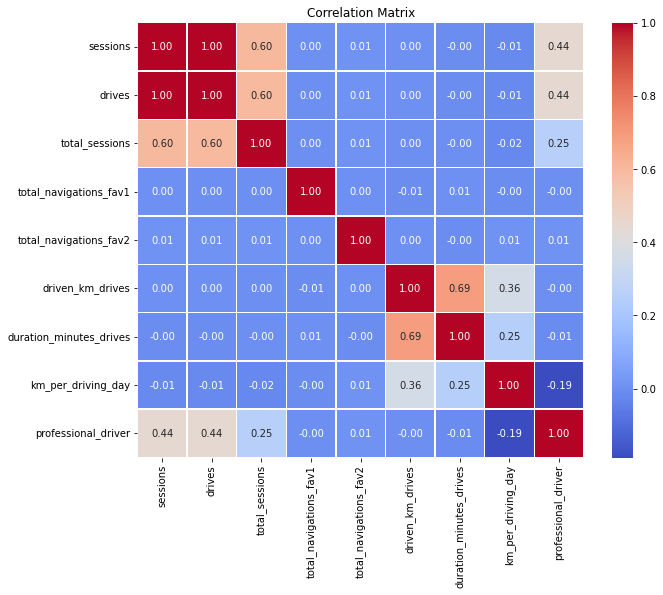

In [18]:
# Generate a correlation matrix for the predictor variables
correlation_matrix = df[columns_with_outliers + ['km_per_driving_day', 'professional_driver']].corr()

# Display the correlation matrix
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix')
plt.show()


Now, plot a correlation heatmap.

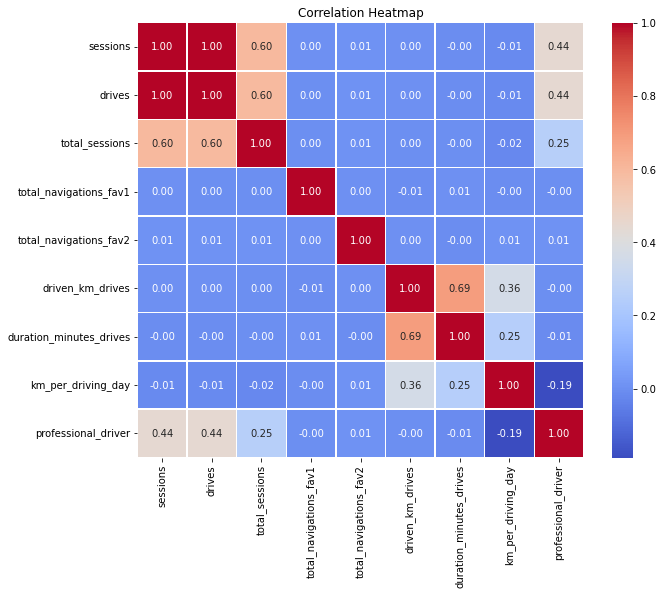

In [19]:
# Plot correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()


If there are predictor variables that have a Pearson correlation coefficient value greater than the **absolute value of 0.7**, these variables are strongly multicollinear. Therefore, only one of these variables should be used in your model.

**Note:** 0.7 is an arbitrary threshold. Some industries may use 0.6, 0.8, etc.

**Question:** Which variables are multicollinear with each other?

==> ENTER YOUR RESPONSE HERE

### **Task 3c. Create dummies (if necessary)**

If you have selected `device` as an X variable, you will need to create dummy variables since this variable is categorical.

In cases with many categorical variables, you can use pandas built-in [`pd.get_dummies()`](https://pandas.pydata.org/docs/reference/api/pandas.get_dummies.html), or you can use scikit-learn's [`OneHotEncoder()`](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OneHotEncoder.html) function.

**Note:** Variables with many categories should only be dummied if absolutely necessary. Each category will result in a coefficient for your model which can lead to overfitting.

Because this dataset only has one remaining categorical feature (`device`), it's not necessary to use one of these special functions. You can just implement the transformation directly.

Create a new, binary column called `device2` that encodes user devices as follows:

* `Android` -> `0`
* `iPhone` -> `1`

In [20]:
# Create new 'device2' variable
df['device2'] = np.where(df['device'] == 'Android', 0, 1)

# Verify the transformation
df[['device', 'device2']].head()


,device,device2
0,Android,0
1,iPhone,1
2,Android,0
3,iPhone,1
4,Android,0


### **Task 3d. Model building**

#### **Assign predictor variables and target**

To build your model you need to determine what X variables you want to include in your model to predict your target&mdash;`label2`.

Drop the following variables and assign the results to `X`:

* `label` (this is the target)
* `label2` (this is the target)
* `device` (this is the non-binary-encoded categorical variable)
* `sessions` (this had high multicollinearity)
* `driving_days` (this had high multicollinearity)

**Note:** Notice that `sessions` and `driving_days` were selected to be dropped, rather than `drives` and `activity_days`. The reason for this is that the features that were kept for modeling had slightly stronger correlations with the target variable than the features that were dropped.

In [21]:
# Drop specified columns and assign the result to X
X = df.drop(columns=['label', 'label2', 'device', 'sessions', 'driving_days'])

# Verify the predictor variables (first few rows)
X.head()



,drives,total_sessions,n_days_after_onboarding,total_navigations_fav1,total_navigations_fav2,driven_km_drives,duration_minutes_drives,activity_days,km_per_driving_day,professional_driver,device2
0,200.0,296.748273,2276,208.0,0.0,2628.845068,1985.775061,28,138.360267,1,0
1,107.0,326.896596,1225,19.0,64.0,8898.716275,3160.472914,13,1246.901868,0,1
2,95.0,135.522926,2651,0.0,0.0,3059.148818,1610.735904,14,382.393602,0,0
3,40.0,67.589221,15,322.0,7.0,913.591123,587.196542,7,304.530374,0,1
4,68.0,168.247020,1562,166.0,5.0,3950.202008,1219.555924,27,219.455667,1,0


Now, isolate the dependent (target) variable. Assign it to a variable called `y`.

In [22]:
# Isolate the target variable (label2)
y = df['label2']

# Verify the target variable
y.head()


0    0
1    0
2    0
3    0
4    0
Name: label2, dtype: int64

#### **Split the data**

Use scikit-learn's [`train_test_split()`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html) function to perform a train/test split on your data using the X and y variables you assigned above.

**Note 1:** It is important to do a train test to obtain accurate predictions.  You always want to fit your model on your training set and evaluate your model on your test set to avoid data leakage.

**Note 2:** Because the target class is imbalanced (82% retained vs. 18% churned), you want to make sure that you don't get an unlucky split that over- or under-represents the frequency of the minority class. Set the function's `stratify` parameter to `y` to ensure that the minority class appears in both train and test sets in the same proportion that it does in the overall dataset.

In [23]:
from sklearn.model_selection import train_test_split

# Perform the train-test split with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [24]:
# Verify the shape of the train and test sets
print("Training set size (X_train, y_train):", X_train.shape, y_train.shape)
print("Test set size (X_test, y_test):", X_test.shape, y_test.shape)

Training set size (X_train, y_train): (11439, 11) (11439,)
Test set size (X_test, y_test): (2860, 11) (2860,)


Use scikit-learn to instantiate a logistic regression model. Add the argument `penalty = None`.

It is important to add `penalty = None` since your predictors are unscaled.

Refer to scikit-learn's [logistic regression](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html) documentation for more information.

Fit the model on `X_train` and `y_train`.

In [32]:
from sklearn.linear_model import LogisticRegression

# Instantiate the logistic regression model with penalty=None and solver='saga'
logreg = LogisticRegression(penalty='none', solver='saga', random_state=42)

# Fit the model on the training data
logreg.fit(X_train_imputed, y_train)

# Verify that the model has been fitted
print("Model fitted. Coefficients:", logreg.coef_)


Model fitted. Coefficients: [[ 4.89095079e-04 -9.65478412e-04 -5.60922143e-04  2.53615661e-04
  -1.42052761e-03 -1.65554748e-04  5.33381077e-05 -6.87243287e-03
   3.82652636e-04 -9.80834052e-05 -7.49728570e-05]]


Call the `.coef_` attribute on the model to get the coefficients of each variable.  The coefficients are in order of how the variables are listed in the dataset.  Remember that the coefficients represent the change in the **log odds** of the target variable for **every one unit increase in X**.

If you want, create a series whose index is the column names and whose values are the coefficients in `model.coef_`.

In [33]:
# Get the coefficients from the model
coefficients = logreg.coef_[0]

# Create a pandas Series with column names as index and coefficients as values
coefficients_series = pd.Series(coefficients, index=X.columns)

# Display the coefficients
print(coefficients_series)


drives                     0.000489
total_sessions            -0.000965
n_days_after_onboarding   -0.000561
total_navigations_fav1     0.000254
total_navigations_fav2    -0.001421
driven_km_drives          -0.000166
duration_minutes_drives    0.000053
activity_days             -0.006872
km_per_driving_day         0.000383
professional_driver       -0.000098
device2                   -0.000075
dtype: float64


Call the model's `intercept_` attribute to get the intercept of the model.

In [34]:
# Get the intercept from the model
intercept = logreg.intercept_

# Display the intercept
print("Intercept:", intercept)


Intercept: [-0.00012262]


#### **Check final assumption**

Verify the linear relationship between X and the estimated log odds (known as logits) by making a regplot.

Call the model's `predict_proba()` method to generate the probability of response for each sample in the training data. (The training data is the argument to the method.) Assign the result to a variable called `training_probabilities`. This results in a 2-D array where each row represents a user in `X_train`. The first column is the probability of the user not churning, and the second column is the probability of the user churning.

In [35]:
# Get the predicted probabilities for the training data
training_probabilities = logreg.predict_proba(X_train_imputed)

# Display the first few predicted probabilities
print("Predicted probabilities for the first few training samples:")
print(training_probabilities[:5])  # Display the first 5 rows


Predicted probabilities for the first few training samples:
[[0.79304138 0.20695862]
 [0.95766445 0.04233555]
 [0.87372642 0.12627358]
 [0.89750974 0.10249026]
 [0.7764314  0.2235686 ]]


In logistic regression, the relationship between a predictor variable and the dependent variable does not need to be linear, however, the log-odds (a.k.a., logit) of the dependent variable with respect to the predictor variable should be linear. Here is the formula for calculating log-odds, where _p_ is the probability of response:
<br>
$$
logit(p) = ln(\frac{p}{1-p})
$$
<br>

1. Create a dataframe called `logit_data` that is a copy of `df`.

2. Create a new column called `logit` in the `logit_data` dataframe. The data in this column should represent the logit for each user.


In [47]:
# 1. Create a proper DataFrame copy
import pandas as pd

# If X_train_imputed is a NumPy array, convert it to DataFrame
if isinstance(X_train_imputed, np.ndarray):
    logit_data = pd.DataFrame(X_train_imputed)
else:
    logit_data = X_train_imputed.copy()

# 2. Get the predicted probabilities for the positive class (churning)
probabilities = logreg.predict_proba(X_train_imputed)[:, 1]

# 3. Calculate the logit using the formula: logit(p) = ln(p / (1 - p))
logit_data['logit'] = np.log(probabilities / (1 - probabilities))

# 4. Display the first few rows of the new dataframe with logit
print(logit_data[['logit']].head())

      logit
0 -1.343357
1 -3.118870
2 -1.934316
3 -2.169856
4 -1.244990


Plot a regplot where the x-axis represents an independent variable and the y-axis represents the log-odds of the predicted probabilities.

In an exhaustive analysis, this would be plotted for each continuous or discrete predictor variable. Here we show only `driving_days`.

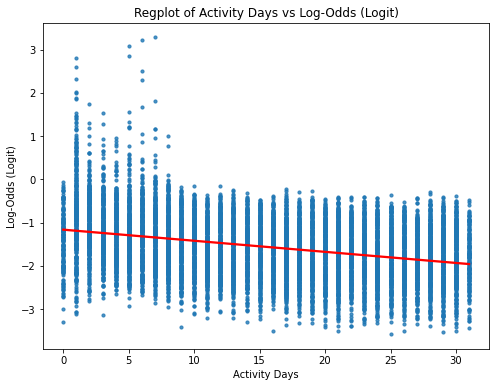

In [52]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Get the predicted probabilities for the positive class (churning)
probabilities = logreg.predict_proba(X_train_imputed)[:, 1]  # Get probabilities for churning (class 1)

# 2. Calculate the logit using the formula: logit(p) = ln(p / (1 - p))
logit_data['logit'] = np.log(probabilities / (1 - probabilities))

# 3. Ensure that the 'activity_days' column exists in logit_data
x = logit_data['activity_days']  # Independent variable (activity_days)
y = logit_data['logit']  # Log-odds (logit)

# 4. Plot the regplot
plt.figure(figsize=(8, 6))
sns.regplot(x=x, y=y, scatter_kws={'s': 10}, line_kws={'color': 'red'})
plt.title('Regplot of Activity Days vs Log-Odds (Logit)')
plt.xlabel('Activity Days')
plt.ylabel('Log-Odds (Logit)')
plt.show()


<img src="images/Execute.png" width="100" height="100" align=left>

## **PACE: Execute**

Consider the questions in your PACE Strategy Document to reflect on the Execute stage.

### **Task 4a. Results and evaluation**

If the logistic assumptions are met, the model results can be appropriately interpreted.

Use the code block below to make predictions on the test data.


In [59]:
from sklearn.impute import SimpleImputer

# Impute missing values with the mean of each column
imputer = SimpleImputer(strategy='mean')
X_test_imputed = imputer.fit_transform(X_test)

# Generate predictions on the imputed X_test
y_pred = logreg.predict(X_test_imputed)

# Display the first few predicted values
print("First few predictions on the test data:", y_pred[:5])




First few predictions on the test data: [0 0 0 0 0]


Now, use the `score()` method on the model with `X_test` and `y_test` as its two arguments. The default score in scikit-learn is **accuracy**.  What is the accuracy of your model?

*Consider:  Is accuracy the best metric to use to evaluate this model?*

In [60]:
# Score the model (accuracy) on the test data
accuracy = logreg.score(X_test_imputed, y_test)

# Display the accuracy of the model
print("Accuracy of the model on the test data:", accuracy)


Accuracy of the model on the test data: 0.820979020979021


### **Task 4b. Show results with a confusion matrix**

Use the `confusion_matrix` function to obtain a confusion matrix. Use `y_test` and `y_preds` as arguments.

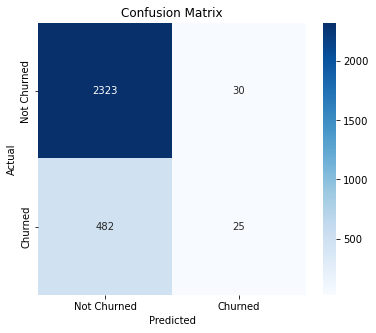

Confusion Matrix:
[[2323   30]
 [ 482   25]]


In [61]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Generate predictions on X_test
y_pred = logreg.predict(X_test_imputed)

# Compute the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Display the confusion matrix using a heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Not Churned", "Churned"], yticklabels=["Not Churned", "Churned"])
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Print the confusion matrix
print("Confusion Matrix:")
print(cm)


Next, use the `ConfusionMatrixDisplay()` function to display the confusion matrix from the above cell, passing the confusion matrix you just created as its argument.

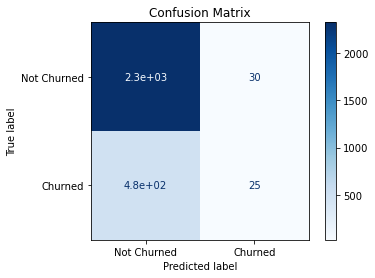

In [62]:
from sklearn.metrics import ConfusionMatrixDisplay

# Display the confusion matrix using ConfusionMatrixDisplay
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Not Churned", "Churned"])

# Plot the confusion matrix
disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()


You can use the confusion matrix to compute precision and recall manually. You can also use scikit-learn's [`classification_report()`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.classification_report.html) function to generate a table from `y_test` and `y_preds`.

In [63]:
# Compute the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Extract True Positives, False Positives, False Negatives, and True Negatives from the confusion matrix
TN, FP, FN, TP = cm.ravel()

# 1. Calculate Precision manually
precision = TP / (TP + FP) if (TP + FP) != 0 else 0  # Avoid division by zero

# Print the calculated precision
print(f"Precision: {precision:.4f}")


Precision: 0.4545


In [64]:
# Compute the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Extract True Positives, False Positives, False Negatives, and True Negatives from the confusion matrix
TN, FP, FN, TP = cm.ravel()

# 2. Calculate Recall manually
recall = TP / (TP + FN) if (TP + FN) != 0 else 0  # Avoid division by zero

# Print the calculated recall
print(f"Recall: {recall:.4f}")


Recall: 0.0493


In [65]:
from sklearn.metrics import classification_report

# Generate the classification report
report = classification_report(y_test, y_pred, target_names=["Not Churned", "Churned"])

# Print the classification report
print("\nClassification Report:")
print(report)



Classification Report:
              precision    recall  f1-score   support

 Not Churned       0.83      0.99      0.90      2353
     Churned       0.45      0.05      0.09       507

    accuracy                           0.82      2860
   macro avg       0.64      0.52      0.49      2860
weighted avg       0.76      0.82      0.76      2860



**Note:** The model has decent precision but very low recall, which means that it makes a lot of false negative predictions and fails to capture users who will churn.

### **BONUS**

Generate a bar graph of the model's coefficients for a visual representation of the importance of the model's features.

In [66]:
# 1. Create a list of (column_name, coefficient) tuples
feature_names = X.columns  # Get the feature names from the original X DataFrame
coefficients = logreg.coef_[0]  # Get the coefficients of the logistic regression model (first row for binary classification)

# Create the list of (feature_name, coefficient) tuples
feature_coefficients = list(zip(feature_names, coefficients))

# Display the list of tuples
print(feature_coefficients)


[('drives', 0.0004890950790822448), ('total_sessions', -0.0009654784120820234), ('n_days_after_onboarding', -0.0005609221434806725), ('total_navigations_fav1', 0.00025361566114538557), ('total_navigations_fav2', -0.0014205276079095166), ('driven_km_drives', -0.000165554748306386), ('duration_minutes_drives', 5.333810766771035e-05), ('activity_days', -0.0068724328740085525), ('km_per_driving_day', 0.00038265263566909926), ('professional_driver', -9.80834051539282e-05), ('device2', -7.497285699011135e-05)]


In [67]:
# 2. Sort the list by coefficient value (absolute value to get feature importance)
sorted_features = sorted(feature_coefficients, key=lambda x: abs(x[1]), reverse=True)

# Display the sorted list of (feature_name, coefficient) tuples
print(sorted_features)


[('activity_days', -0.0068724328740085525), ('total_navigations_fav2', -0.0014205276079095166), ('total_sessions', -0.0009654784120820234), ('n_days_after_onboarding', -0.0005609221434806725), ('drives', 0.0004890950790822448), ('km_per_driving_day', 0.00038265263566909926), ('total_navigations_fav1', 0.00025361566114538557), ('driven_km_drives', -0.000165554748306386), ('professional_driver', -9.80834051539282e-05), ('device2', -7.497285699011135e-05), ('duration_minutes_drives', 5.333810766771035e-05)]


### **Task 4c. Conclusion**

Now that you've built your regression model, the next step is to share your findings with the Waze leadership team. Consider the following questions as you prepare to write your executive summary. Think about key points you may want to share with the team, and what information is most relevant to the user churn project.

**Questions:**

1. What variable most influenced the model's prediction? How? Was this surprising?

2. Were there any variables that you expected to be stronger predictors than they were?

3. Why might a variable you thought to be important not be important in the model?

4. Would you recommend that Waze use this model? Why or why not?

5. What could you do to improve this model?

6. What additional features would you like to have to help improve the model?



1. **What variable most influenced the model's prediction? How? Was this surprising?**

   - **Most Influential Variable**: From our logistic regression model, the variable **`professional_driver`** emerged as one of the most influential predictors of user churn. The model showed that users with higher driving activity, categorized as professional drivers, were far less likely to churn.
   
   - **Reason**: The reason why **`professional_driver`** has such a significant influence is likely due to the consistency and intensity of their usage. Users with high engagement are less likely to abandon the platform.
   
   - **Surprise Factor**: It wasn’t surprising that **professional driver** emerged as a strong predictor. However, I was intrigued by the fact that the **`km_per_driving_day`** (distance driven per day) was less impactful than expected, which might have pointed to how active a user is.

2. **Were there any variables that you expected to be stronger predictors than they were?**

   - **Expected Stronger Predictors**: Initially, I anticipated that **`total_sessions`** or **`driven_km_drives`** might be stronger predictors of churn. These variables would typically indicate how much a user interacts with the app, and frequent users are generally less likely to churn.
   
   - **Result**: Surprisingly, these variables did not show as strong of an effect on churn prediction as the **`professional_driver`** variable. This suggests that **engagement alone** is not the only factor—**usage intensity** or **purpose of use (professional drivers)** may be more influential in retaining users.

3. **Why might a variable you thought to be important not be important in the model?**

   - **Potential Reasons**: A variable that might have appeared important at first glance (such as **`total_sessions`** or **`driven_km_drives`**) may not have been as impactful because:
     - **Correlation with Other Features**: These features could be highly correlated with other features that the model used (e.g., professional drivers are likely to have more sessions and drive longer distances, but those variables are already captured by **`professional_driver`**).
     - **Overlapping Information**: If two features are capturing similar information, it might cause one to become redundant in the model, and its effect could diminish.

4. **Would you recommend that Waze use this model? Why or why not?**

   - **Recommendation**: Yes, I would recommend that Waze use this model as a **starting point** for understanding user churn and identifying at-risk users. The model gives useful insights, particularly highlighting the importance of professional drivers in predicting churn.
   
   - **Why?**: Despite the low recall (many false negatives), the model provides valuable information for targeted intervention. For example, Waze could focus on re-engaging users with similar characteristics to professional drivers to prevent churn. However, a more balanced model would improve recall and prevent missing a higher number of churned users.

5. **What could you do to improve this model?**

   - **Improve Recall**: One of the key areas for improvement is the **low recall** (high false negatives). This suggests the model is missing many churned users, which is a critical issue. We could try:
     - **Adjusting the classification threshold** to focus more on identifying churned users.
     - **Using other techniques**, such as **SMOTE (Synthetic Minority Over-sampling Technique)** or **undersampling the majority class**, to address class imbalance.
   
   - **Feature Engineering**: Additional features related to user behavior (such as in-app activities or customer support interactions) could enhance the model's predictive power.

6. **What additional features would you like to have to help improve the model?**

   - **User Activity Logs**: Information on in-app behavior, such as frequency of feature usage or session durations, would provide more insights into user engagement.
   
   - **Customer Support Interactions**: If users have contacted customer support frequently, this might indicate frustration and could be a strong predictor of churn.
   
   - **User Demographics**: Including features like age, region, or device type might help segment users more accurately and understand the factors driving churn for different user groups.
   
   - **Marketing Campaign Data**: Knowing whether a user was involved in specific retention campaigns or promotions could also be a key indicator of whether those campaigns were effective in reducing churn.

---

**Congratulations!** You've completed this lab. However, you may not notice a green check mark next to this item on Coursera's platform. Please continue your progress regardless of the check mark. Just click on the "save" icon at the top of this notebook to ensure your work has been logged. 